_preprocess stage_

Encoder fonde dati eterogenei (satellite, modelli, sensori) per produrre uno stato atmosferico
iniziale coerente su una griglia uniforme.

NOAA APT Satellite Images: These are low-earth-orbit weather satellite images (e.g. from
 NOAA-15/18) with ~4 km/pixel resolution, typically two channels (infrared and visible) broadcast
 via Automatic Picture Transmission.

Open Oceanographic/Meteorological API Data: This includes buoy measurements (e.g. wave
 height, sea temperature), weather radar snapshots (e.g. precipitation radar images), and ship
 observations. 


---------------------------------------------------------------------------------------------------------
All data must be mapped to a common geospatial
 grid. Define a latitude-longitude grid covering the Western Mediterranean at the desired
 resolution (1 km × 1 km).

Interpolate point data (buoys, ship observations) onto this grid. A simple approach is nearest
neighbor or inverse-distance weighting for each variable. Satellite and radar data, which may
 come as images or their own grids, should be reprojected or resampled onto the common grid.

Normalization: Once all data layers are on the same grid, stack them into a multi-channel array.
Normalize each channel (e.g. min-max scaling or z-score) so that different data ranges are comparable for the model.

DN --> BT (Planck Approach) TIF FILE

bit_depth from product.json: 8
DN raster: (1288, 909) float32
Pseudo-BT stats: min=212.50, max=339.50, mean=276.16
Written pseudo-BT GeoTIFF: ..\Georeferencer\APT_BT_pseudo.tif


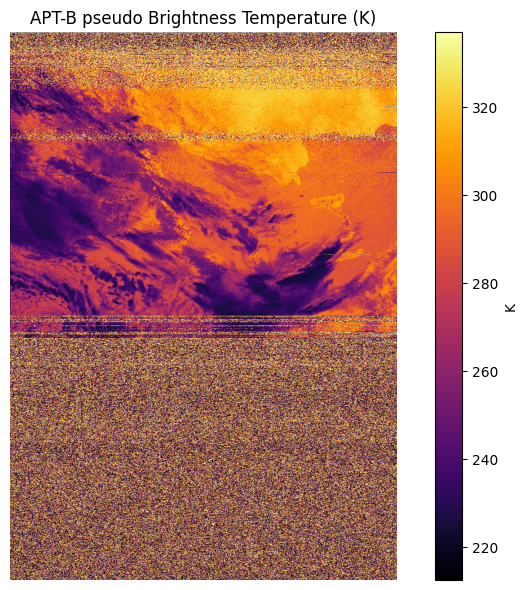

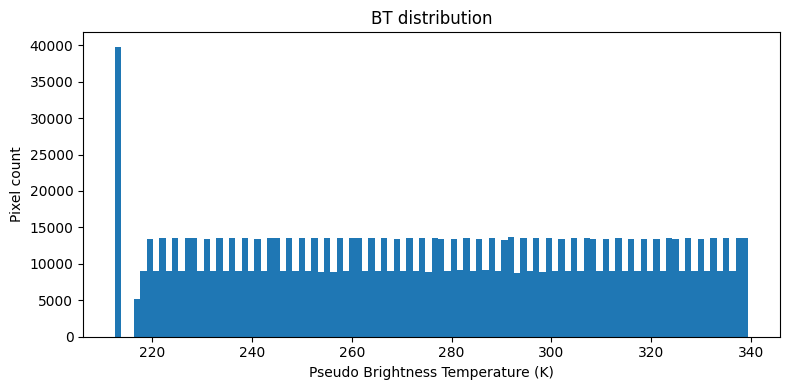

In [7]:
import json
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import csv

# --------------------------
# PATH CONFIG
# --------------------------
PRODUCT_JSON_PATH = r"..\Georeferencer\product.json"
INPUT_DN_TIF      = r"..\Georeferencer\APT_georef_physical.tif"  # tuo GeoTIFF DN invariati
OUTPUT_BT_TIF     = r"..\Georeferencer\APT_BT_pseudo.tif"

# --------------------------
# 1. LOAD METADATA
# --------------------------
with open(PRODUCT_JSON_PATH, "r") as f:
    product = json.load(f)

bit_depth = product.get("bit_depth", 8)
print("bit_depth from product.json:", bit_depth)

# --------------------------
# 2. READ DN (8-bit) GEOREFERENCED IMAGE
# --------------------------
with rasterio.open(INPUT_DN_TIF) as src:
    dn = src.read(1).astype(np.float32)
    profile = src.profile
    gcps, gcp_crs = src.gcps

print("DN raster:", dn.shape, dn.dtype)

# --------------------------
# 3. NORMALISE TO 0–255 (ROBUST)
# --------------------------
if bit_depth != 8:
    max_dn = float(2**bit_depth - 1)
    dn_8 = np.clip(dn, 0, max_dn) * (255.0 / max_dn)
else:
    dn_8 = np.clip(dn, 0, 255.0)

background_mask = (dn_8 <= 0)

# --------------------------
# 4. PSEUDO-BT NOAA PER APT
#    Tb = 340 - 0.5 * D
# --------------------------
Tb = 340.0 - 0.5 * dn_8
Tb = Tb.astype("float32")
Tb[background_mask] = np.nan

print(f"Pseudo-BT stats: min={np.nanmin(Tb):.2f}, "
      f"max={np.nanmax(Tb):.2f}, mean={np.nanmean(Tb):.2f}")

# --------------------------
# 5. WRITE BT GeoTIFF
# --------------------------
bt_profile = profile.copy()
bt_profile.update(
    dtype="float32",
    count=1,
    nodata=np.nan
)

with rasterio.open(OUTPUT_BT_TIF, "w", **bt_profile) as dst:
    dst.write(Tb, 1)
    if gcps:
        dst.gcps = (gcps, gcp_crs)
    dst.update_tags(1,
        quantity="brightness_temperature_proxy",
        units="K",
        conversion="Tb = 340 - 0.5 * D (APT empirical approximation)",
        source_bit_depth=str(bit_depth)
    )

print("Written pseudo-BT GeoTIFF:", OUTPUT_BT_TIF)

# --------------------------
# 6. PLOT MAP + HISTOGRAM
# --------------------------
valid = Tb[~np.isnan(Tb)]

plt.figure(figsize=(8, 6))
im = plt.imshow(
    Tb,
    cmap="inferno",
    vmin=np.nanpercentile(Tb, 2),
    vmax=np.nanpercentile(Tb, 98),
)
plt.title("APT-B pseudo Brightness Temperature (K)")
plt.colorbar(im, label="K")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(valid, bins=100)
plt.xlabel("Pseudo Brightness Temperature (K)")
plt.ylabel("Pixel count")
plt.title("BT distribution")
plt.tight_layout()
plt.show()


In [11]:
import rasterio 
import numpy as np
import csv
from tqdm import tqdm
from rasterio import warp

INPUT_TIF = "..\Georeferencer\APT_BT_pseudo.tif"
OUTPUT_CSV = "APT-B.csv"

# ----------------------------
# 1. LEGGI TIFF + GCP GEOMETRY
# ----------------------------
with rasterio.open(INPUT_TIF) as src:
    dn = src.read(1).astype(float)
    transform = src.transform
    gcps, gcps_crs = src.gcps

    # rasterio permette di trasformare pixel→coordinate usando i GCP
    # ma devi costruire un transformer apposito
    transformer = src.gcps[0], src.gcps[1]

# ----------------------------
# 2. PREPARA CSV
# ----------------------------
h, w = dn.shape

with open(OUTPUT_CSV, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["lat", "lon", "dn"])

    # ------------------------------------
    # pixel→lat/lon usando GCP interpolation
    # ------------------------------------
    with rasterio.open(INPUT_TIF) as src:
        for row in tqdm(range(h), desc="Exporting CSV"):
            cols = np.arange(w)
            rows = np.full(w, row)

            # usa rasterio.transformer per ottenere coordinate WGS84
            lons, lats = rasterio.transform.xy(src.transform, rows, cols, offset="center")
            # ma src.transform è identity → usa GCP-based transform:
            lats, lons = rasterio.warp.transform(
                gcps_crs,
                "EPSG:4326",
                lons,
                lats,
                zs=None
            )

            # scrivi righe CSV
            for col in range(w):
                writer.writerow([lats[col], lons[col], dn[row, col]])

print(f"CSV saved as: {OUTPUT_CSV}")


Exporting CSV: 100%|██████████| 1288/1288 [00:02<00:00, 438.15it/s]

CSV saved as: APT-B.csv


In [ ]:
import json
import numpy as np

# ==============================
# 0. PATHS
# ==============================
DATASET_JSON_PATH = "product.json"   # <-- metti qui il path reale

# ==============================
# 1. LOAD dataset.json
# ==============================
with open(DATASET_JSON_PATH, "r") as f:
    dataset = json.load(f)

bit_depth = dataset.get("bit_depth", 8)
print(f"bit_depth = {bit_depth}")

calib = dataset.get("calibration", {})
per_channel = calib.get("vars", {}).get("perChannel", [])
wavenumbers = calib.get("wavenumbers", [])

if not per_channel:
    raise ValueError("No 'calibration.vars.perChannel' block found in dataset.json")

print(f"Found {len(per_channel)} channel calibration entries")
print("Wavenumbers list:", wavenumbers)

# ==============================
# 2. SELECT A THERMAL CHANNEL (e.g. ~930 cm^-1 → AVHRR ch.4)
# ==============================
target_ch = None
target_index = None

for i, ch in enumerate(per_channel):
    wn = ch.get("wavnb", None)
    if wn is None:
        continue
    # Window band around ~930 cm^-1 (10.8 µm)
    if 900.0 <= wn <= 1000.0:
        target_ch = ch
        target_index = i
        break

if target_ch is None:
    raise ValueError(
        "No thermal channel in the 900–1000 cm^-1 range found "
        "in 'calibration.vars.perChannel'."
    )

print(f"\nUsing thermal channel index {target_index} with wavnb = {target_ch['wavnb']} cm^-1")

# Extract calibration parameters for this channel
Vc = float(target_ch.get("Vc", target_ch.get("wavnb")))  # central wavenumber [cm^-1]
A  = float(target_ch.get("A"))
B  = float(target_ch.get("B"))
b  = target_ch.get("b", [])
b  = [float(x) for x in b]

# Optional: other fields present
Nbb = target_ch.get("Nbb", None)
Ns  = target_ch.get("Ns", None)
Blb = target_ch.get("Blb", None)
Spc = target_ch.get("Spc", None)

print("\nCalibration coefficients for selected channel:")
print(f"  Vc            = {Vc} cm^-1")
print(f"  A, B          = {A}, {B}")
print(f"  b coefficients= {b}")
print(f"  Nbb (if any)  = {Nbb}")
print(f"  Ns  (if any)  = {Ns}")
print(f"  Blb (if any)  = {Blb}")
print(f"  Spc (if any)  = {Spc}")

# ==============================
# 3. PLANCK INVERSION: L → T'
# ==============================

def radiance_to_bt_planck(L, vc_cm):
    """
    Convert spectral radiance L [W/(m^2 sr cm^-1)]
    to uncorrected brightness temperature T' [K]
    using AVHRR-style Planck inversion:

        T' = c2 * ν / ln(1 + (c1 * ν^3) / L)

    where ν = vc_cm in cm^-1 and c1, c2 are Planck constants
    expressed in units consistent with L and ν.
    """
    # Planck constants in units consistent with L in W/(m^2 sr cm^-1)
    # and ν in cm^-1. These are the standard AVHRR-style constants.
    c1 = 1.191042e-5  # W m^2 sr^-1 (cm^4)
    c2 = 1.4387752    # K cm

    nu = float(vc_cm)

    # Avoid division by zero or negative radiances
    L_safe = np.maximum(L, 1e-10)

    T_prime = (c2 * nu) / np.log(1.0 + (c1 * nu**3) / L_safe)
    return T_prime

# ==============================
# 4. NONLINEARITY CORRECTION: T' → T
# ==============================

def nonlinear_bt_correction(T_prime, A, B, b):
    """
    Apply AVHRR nonlinearity correction:

        T = A + B*T' + b1*T'^2 + b2*T'^3 + ...

    where b is a list of polynomial coefficients [b1, b2, b3?].
    """
    T_corr = A + B * T_prime

    if len(b) > 0:
        T_corr += b[0] * T_prime**2
    if len(b) > 1:
        T_corr += b[1] * T_prime**3
    if len(b) > 2:
        # If a 4th-order term exists, interpret b[2] as coefficient
        T_corr += b[2] * T_prime**4

    return T_corr

# ==============================
# 5. PLACEHOLDER: LOAD OR DEFINE RADIANCE FIELD L
# ==============================
"""
IMPORTANT:

dataset.json (your example) contains only metadata (bit_depth,
calibration, wavenumbers, image file names, projection_cfg, etc.)
and does NOT store a radiance array.

For true Level-1 processing, L must come from AVHRR Level-1 data
(e.g. HRPT/LAC/GAC radiance for the selected channel), not from
APT PNGs.

Here we create a dummy radiance array just to show how the
calibration functions are used. Replace this with your real
radiance field L_ch, e.g.:

    L = np.load('radiance_ch4.npy')

or whatever source you use for Level-1 radiances.
"""

# Example dummy field: 100x100 pixels, constant 5 W/(m^2 sr cm^-1)
L = np.full((100, 100), 5.0, dtype=np.float64)

# ==============================
# 6. COMPUTE T' AND FINAL BT
# ==============================
T_prime = radiance_to_bt_planck(L, Vc)
T_bt    = nonlinear_bt_correction(T_prime, A, B, b)

print("\nT' (uncorrected BT) stats on dummy radiance:")
print(f"  min = {np.nanmin(T_prime):.2f} K")
print(f"  max = {np.nanmax(T_prime):.2f} K")
print(f"  mean= {np.nanmean(T_prime):.2f} K")

print("\nFinal brightness temperature T stats:")
print(f"  min = {np.nanmin(T_bt):.2f} K")
print(f"  max = {np.nanmax(T_bt):.2f} K")
print(f"  mean= {np.nanmean(T_bt):.2f} K")

# ==============================
# 7. OPTIONAL: SAVE BT FIELD
# ==============================
np.save("BT_channel_window_dummy.npy", T_bt)
print("\nSaved BT array to 'BT_channel_window_dummy.npy'")


CLOUD IDENTIFICATION

In [2]:
import numpy as np
import pandas as pd
import rasterio

# ============================
# PARAMETRI
# ============================

# GeoTIFF MCIR_Rain in ingresso (RGB, georeferenziato)
GEOTIFF_PATH = r"..\Georeferencer\APT_georef_physical.tif"

# File con le coordinate lat/lon per ogni pixel
COORDS_PATH = "..\Georeferencer\coords_latlon.npz"      # contiene array 'latlon' shape (H, W, 2)

# CSV di output
CSV_OUT = "cloud_risk_map.csv"

# Tolleranza sul colore (0–255) per catturare pixel "simili"
COLOR_TOL = 10

# Mappa: label -> (RGB_target, rischio_estremo_%)
# nero   = probabilità molto alta / evento estremo
# rosso  = probabilità alta
# giallo = probabilità media
# verde  = probabilità bassa
PALETTE = {
    "extreme": ((0,   0,   0  ), 100),  # nero
    "high":    ((255, 0,   0  ), 75),   # rosso
    "medium":  ((255, 255, 0  ), 50),   # giallo
    "low":     ((0,   255, 0  ), 25),   # verde
}

# ============================
# FUNZIONE PER MASCHERA COLORE
# ============================

def color_mask(rgb_array, target_rgb, tol=5):
    """
    rgb_array : array (H, W, 3) uint8
    target_rgb: (R, G, B)
    tol       : tolleranza assoluta per canale (0-255)

    Ritorna una maschera booleana (H, W) True dove il colore è
    vicino al target entro la tolleranza.
    """
    target = np.array(target_rgb, dtype=np.int16)
    arr = rgb_array.astype(np.int16)
    diff = np.abs(arr - target[None, None, :])
    mask = np.all(diff <= tol, axis=-1)
    return mask

# ============================
# LETTURA RASTER E COSTRUZIONE RGB
# ============================

with rasterio.open(GEOTIFF_PATH) as src:
    R = src.read(1)
    G = src.read(2)
    B = src.read(3)
    crs = src.crs
    print("CRS:", crs)
    print("Shape bande:", R.shape)

rgb = np.stack([R, G, B], axis=-1)  # (H, W, 3)
height, width, _ = rgb.shape

# ============================
# LETTURA COORDINATE LAT/LON
# ============================

coords = np.load(COORDS_PATH)["latlon"]   # shape (H, W, 2)
lat_grid = coords[:, :, 0]
lon_grid = coords[:, :, 1]

# Controllo di coerenza dimensioni
assert coords.shape[0] == height and coords.shape[1] == width, \
    f"Dimensioni mismatch: raster {rgb.shape} vs coords {coords.shape}"

# ============================
# CLASSIFICAZIONE PIXEL
# ============================

all_lats = []
all_lons = []
all_labels = []
all_risks = []

for label, (rgb_target, risk_pct) in PALETTE.items():
    print(f"Classifico colore {label} con target RGB {rgb_target}...")
    mask = color_mask(rgb, rgb_target, tol=COLOR_TOL)

    rows, cols = np.where(mask)
    print(f"  Pixel trovati: {len(rows)}")

    if len(rows) == 0:
        continue

    # Preleva lat/lon dai grid già pronti
    sel_lats = lat_grid[rows, cols]
    sel_lons = lon_grid[rows, cols]

    all_lats.extend(sel_lats.tolist())
    all_lons.extend(sel_lons.tolist())
    all_labels.extend([label] * len(sel_lats))
    all_risks.extend([risk_pct] * len(sel_lats))

# ============================
# COSTRUZIONE DATAFRAME E SALVATAGGIO CSV
# ============================

df = pd.DataFrame({
    "lat": all_lats,
    "lon": all_lons,
    "label": all_labels,
    "risk_extreme_pct": all_risks,
})

df = df.sort_values(["lat", "lon"]).reset_index(drop=True)

df.to_csv(CSV_OUT, index=False)
print(f"CSV salvato in: {CSV_OUT}")
print("Numero totale di pixel classificati:", len(df))
print(df.head())


CRS: None
Shape bande: (1725, 909)
Classifico colore extreme con target RGB (0, 0, 0)...
  Pixel trovati: 23725
Classifico colore high con target RGB (255, 0, 0)...
  Pixel trovati: 9448
Classifico colore medium con target RGB (255, 255, 0)...
  Pixel trovati: 13370
Classifico colore low con target RGB (0, 255, 0)...
  Pixel trovati: 13876
CSV salvato in: cloud_risk_map.csv
Numero totale di pixel classificati: 60419
         lat        lon label  risk_extreme_pct
0  14.712043  17.558032   low                25
1  14.752293  18.533051   low                25
2  14.836222  18.559780   low                25
3  14.888162  16.931161   low                25
4  14.953597  18.194983   low                25


In [ ]:
 import requests, json
 from PIL import Image
 import numpy as np
 # Define grid parameters (example bounds and resolution)
 
 lat_min, lat_max = 30.0, 45.0
 lon_min, lon_max =-5.0, 15.0
 res_deg = 0.01 # ~1 km
 lat_vals = np.arange(lat_min, lat_max, res_deg)
 lon_vals = np.arange(lon_min, lon_max, res_deg)
 NY, NX = len(lat_vals), len(lon_vals)
 
 # Initialize multichannel grid (e.g. 6 channels)
 data_grid = np.zeros((6, NY, NX), dtype=np.float32)
 
 # 1. Fetch latest NOAA APT satellite image (simulate by loading from file or URL)
 sat_img = Image.open("noaa_apt_latest.jpg") # placeholder for actual fetch
 sat_arr = np.array(sat_img.convert("L")) # convert to grayscale numpy array

 # Resample satellite image to grid resolution:
 # (In practice, use PIL resize or cv2.remap for projection. Here assume already aligned.)
 sat_arr_resized = np.array(sat_img.resize((NX, NY)))
 data_grid[0,:,:] = sat_arr_resized # e.g. IR channel

 # If APT has a second channel (e.g. visible), place it in data_grid[1]

 # 2. Fetch buoy data from an open API (e.g. NOAA NDBC or Copernicus Marine)

 buoy_url = "https://api.example.com/latest_buoys?region=med"
 resp = requests.get(buoy_url)
 buoy_data = resp.json() # assume JSON with list of {lat, lon, value} for some variable
 for buoy in buoy_data["stations"]:
 lat, lon = buoy["latitude"], buoy["longitude"]
 val = buoy["measurement"]["value"]
 # Find nearest grid index
 iy = int((lat-lat_min) / res_deg)
 ix = int((lon-lon_min) / res_deg)
 if 0 <= iy < NY and 0 <= ix < NX:
 data_grid[2, iy, ix] = val # e.g. assign sea surface temp at buoy location

 # 3. Fetch radar data (e.g. rainfall radar composite)
 radar_img_data = requests.get("https://openapi.example.com/radar/med_latest.png").content
 with open("radar.png", "wb") as f:
 f.write(radar_img_data)
 radar_img = Image.open("radar.png")
 radar_arr = np.array(radar_img.convert("L"))
 # Assume radar image already in lat/lon projection for region; resample to grid
 radar_arr_resized = np.array(radar_img.resize((NX, NY)))
 data_grid[3,:,:] = radar_arr_resized # e.g. rainfall intensity

 # 4. Fetch ship observations (if available) similar to buoy
 ship_url = "https://api.example.com/ships/meteo"
 ship_data = requests.get(ship_url).json()
 for obs in ship_data["observations"]:
 lat, lon = obs["lat"], obs["lon"]
 wind = obs["wind_speed"]
 iy = int((lat- lat_min) / res_deg); ix = int((lon- lon_min) / res_deg)
 if 0 <= iy < NY and 0 <= ix < NX:
 data_grid[4, iy, ix] = wind # place ship-reported wind speed

 # 5. Interpolate missing values on the grid if necessary:
 # For simplicity, fill small gaps via nearest neighbor
 for ch in range(data_grid.shape[0]):
 layer = data_grid[ch]
 mask = (layer == 0) # assuming 0 means no data; in practice use NaN
 if mask.any():
 # simple nearest neighbor fill
 coords = np.array(np.nonzero(~mask)).T
 vals = layer[~mask]
 from scipy import spatial
 tree = spatial.KDTree(coords)
 missing_coords = np.array(np.nonzero(mask)).T
 nearest = tree.query(missing_coords)[1]
 layer[mask] = vals[nearest]
 data_grid[ch] = layer

 # 6. Normalization (e.g., scale each channel 0-1)
 for ch in range(data_grid.shape[0]):
 arr = data_grid[ch]
 data_grid[ch] = (arr- np.nanmin(arr)) / (np.nanmax(arr)- np.nanmin(arr)
 + 1e-6)

In [1]:
import requests, json
from PIL import Image, TiffImagePlugin
import numpy as np

# -------------------------
# Parametri della griglia
# -------------------------
lat_min, lat_max = 30.0, 46.0      
lon_min, lon_max = -5.0, 15.0
res_deg = 0.01
lat_vals = np.arange(lat_min, lat_max, res_deg)
lon_vals = np.arange(lon_min, lon_max, res_deg)
NY, NX = len(lat_vals), len(lon_vals)

# Griglia multicanale (9 canali):
# 0: AVHRR A (L), 1: AVHRR B (L), 2: MCIR Rain (L),
# 3: WSPD (vento), 4: VTDH (onde), 5: TEMP (sea water temperature), 6: ATMS (pressione),
# 7: radar, 8: navi
data_grid = np.zeros((9, NY, NX), dtype=np.float32)

# -------------------------
# 1) Caricamento TIFF AVHRR A, B e MCIR Rain
# -------------------------
def open_first_page_tiff(path):
    img = Image.open(path)
    try:
        if hasattr(img, "n_frames") and img.n_frames > 1:
            img.seek(0)
    except Exception:
        pass
    return img

img_A = open_first_page_tiff("avhrr_3_APT_channel_A.tif").convert("L")
arr_A = np.array(img_A.resize((NX, NY)), dtype=np.float32)
data_grid[0, :, :] = arr_A

img_B = open_first_page_tiff("avhrr_3_APT_channel_B.tif").convert("L")
arr_B = np.array(img_B.resize((NX, NY)), dtype=np.float32)
data_grid[1, :, :] = arr_B

img_MCIR = open_first_page_tiff("avhrr_3_rgb_MCIR_Rain_(Uncalibrated).tif")
if img_MCIR.mode != "RGB":
    img_MCIR = img_MCIR.convert("RGB")
img_MCIR_L = img_MCIR.convert("L")
arr_MCIR_L = np.array(img_MCIR_L.resize((NX, NY)), dtype=np.float32)
data_grid[2, :, :] = arr_MCIR_L


c:\Users\Davide\anaconda3\envs\geoenv\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
from datetime import datetime, timedelta, timezone
from pathlib import Path
import pandas as pd
import copernicusmarine as cm
import xarray as xr
import os
import sys
import glob

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURAZIONE
dataset_id = "cmems_obs-ins_med_phybgcwav_mynrt_na_irr"

# Bounding box Adriatico intero
lat_min, lat_max = 39.0, 46.5
lon_min, lon_max = 12.0, 20.0

# Finestra temporale (ultime 24 ore)
t_end = datetime.now(timezone.utc)
t_start = t_end - timedelta(hours=24)

# Variabili d’interesse
wanted = ["VHM0", "VTDH", "SWH", "WVHT", "TEMP", "WTMP", "ATMS", "MSLP"]

# File lista per cm.get
filelist_path = "files_to_get.txt"

# Output metadati
vars_csv = "metadata_variables.csv"
globs_csv = "metadata_globals.csv"

# Output merge finale
merged_csv = "adriatic_observations.csv"
# ─────────────────────────────────────────────────────────────────────────────

print("1) Scarico gli index files…")
cm.get(dataset_id=dataset_id, index_parts=True, no_directories=True)

print("2) Cerco l'index_latest.txt…")
candidates = list(Path(".").glob("index_latest.txt"))
if not candidates:
    candidates = list(Path(".").glob(
        "INSITU_MED_PHYBGCWAV_DISCRETE_MYNRT_013_035/"
        "cmems_obs-ins_med_phybgcwav_mynrt_na_irr_*/index_latest.txt"
    ))
if not candidates:
    print("ERRORE: index_latest.txt non trovato.")
    sys.exit(1)

idx_path = str(sorted(candidates)[-1])
print(f"   → uso: {idx_path}")

print("3) Leggo l'indice e applico i filtri…")
# saltare 5 righe di metadati per avere intestazioni corrette
df = pd.read_csv(idx_path, sep=",", skiprows=5)
df.columns = [c.strip().lstrip("#") for c in df.columns]

# --- FILTRI ---
# Geo: SOLO Adriatico (intersezione bbox con bbox granulo)
mask_geo = (
    (df["geospatial_lat_max"] >= lat_min) &
    (df["geospatial_lat_min"] <= lat_max) &
    (df["geospatial_lon_max"] >= lon_min) &
    (df["geospatial_lon_min"] <= lon_max)
)

# Tempo: intersezione con [t_start, t_end]
t_start_col = pd.to_datetime(df["time_coverage_start"], utc=True, errors="coerce")
t_end_col   = pd.to_datetime(df["time_coverage_end"],   utc=True, errors="coerce")
mask_time = (t_end_col >= t_start) & (t_start_col <= t_end)

# Variabili: almeno una tra 'wanted'
mask_vars = df["parameters"].astype(str).apply(lambda s: any(v in s for v in wanted))

sel = df[mask_geo & mask_time & mask_vars].copy()
sel = sel.dropna(subset=["file_name"]).drop_duplicates(subset=["file_name"])

print(f"   → Granuli selezionati: {len(sel)}")
if len(sel) == 0:
    print("Nessun file trovato per i filtri scelti.")
    sys.exit(0)

# salva lista file per download
sel["file_name"].to_csv(filelist_path, index=False, header=False, encoding="utf-8")
print(f"   → Lista salvata in: {os.path.abspath(filelist_path)}")

print("4) Scarico i file selezionati…")
cm.get(dataset_id=dataset_id, file_list=filelist_path, no_directories=True)

# ─────────────────────────────────────────────────────────────────────────────
# 5) Estrazione METADATI → CSV
print("\n5) Estraggo i metadati…")

var_rows = []
glob_rows = []

for fn in sel["file_name"].astype(str).tolist():
    local_fn = os.path.basename(fn)  # no_directories=True → basename nella CWD
    if not Path(local_fn).exists():
        print(f"   ! File non trovato localmente (saltato): {local_fn}")
        continue

    ds = xr.open_dataset(local_fn)

    # Attributi globali (una riga per attributo)
    for k, v in ds.attrs.items():
        glob_rows.append({"file": local_fn, "attribute": k, "value": v})

    # Variabili (una riga per variabile)
    for var in ds.data_vars:
        attrs = ds[var].attrs or {}
        var_rows.append({
            "file": local_fn,
            "variable": var,
            "units": attrs.get("units", ""),
            "long_name": attrs.get("long_name", ""),
            "standard_name": attrs.get("standard_name", ""),
            "coordinates": attrs.get("coordinates", ""),
            "comment": attrs.get("comment", "")
        })

    ds.close()

# Scrivi CSV metadati
pd.DataFrame(var_rows).to_csv(vars_csv, index=False, encoding="utf-8")
pd.DataFrame(glob_rows).to_csv(globs_csv, index=False, encoding="utf-8")
print(f"   • Metadati variabili: {os.path.abspath(vars_csv)}")
print(f"   • Metadati globali  : {os.path.abspath(globs_csv)}")

# ─────────────────────────────────────────────────────────────────────────────
# 6) Esporta i DATI osservati (serie temporali) in CSV per ogni NetCDF
print("\n6) Estraggo i dati osservati (per-file)…")

per_file_csvs = []

for fn in sel["file_name"].astype(str).tolist():
    local_fn = os.path.basename(fn)
    if not Path(local_fn).exists():
        continue

    ds = xr.open_dataset(local_fn)

    # converti dataset in tabella: include coordinate (es. time, lat, lon) e variabili
    try:
        df_data = ds.to_dataframe().reset_index()
        # aggiungi il nome file (utile nel merge)
        df_data.insert(0, "source_file", local_fn)
        out_csv = local_fn.replace(".nc", "_data.csv")
        df_data.to_csv(out_csv, index=False, encoding="utf-8")
        per_file_csvs.append(out_csv)
        print(f"  Dati salvati: {out_csv}")
    except Exception as e:
        print(f"  Errore su {local_fn}: {e}")

    ds.close()

if not per_file_csvs:
    print("   Nessun CSV per-file generato; salto il merge finale.")
    sys.exit(0)

# ─────────────────────────────────────────────────────────────────────────────
# 7) Merge finale di tutti i *_data.csv in un unico CSV
print("\n7) Fondere tutti i CSV in un unico file…")

dfs = []
for path in per_file_csvs:
    try:
        dfp = pd.read_csv(path)
        dfs.append(dfp)
    except Exception as e:
        print(f" Impossibile leggere {path}: {e}")

# concat unione colonne (outer) per tollerare file con variabili diverse
if dfs:
    merged = pd.concat(dfs, ignore_index=True, sort=False)
    # ordina colonne in modo leggibile: file, time (se presente), poi il resto
    cols = list(merged.columns)
    ordered = []
    for key in ["source_file", "time", "TIME", "date_time", "datetime"]:
        if key in cols:
            ordered.append(key)
    for c in cols:
        if c not in ordered:
            ordered.append(c)
    merged = merged[ordered]
    merged.to_csv(merged_csv, index=False, encoding="utf-8")
    print(f"  Merge completato: {os.path.abspath(merged_csv)}")
else:
    print("   Nessun dataframe da fondere.")

print("\n Finito!")
print("   - CSV metadati globali e variabili creati")
print("   - CSV per-file creati")
print("   - CSV unico con tutte le osservazioni dell’Adriatico creato")


c:\Users\Davide\anaconda3\envs\geoenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1) Scarico gli index files…


KeyboardInterrupt: 

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
FVG – latest per sensore → CSV per stazione (coastal only)
Usa i path e le strutture del tuo Swagger (risposte wrappate).
"""

import time
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import requests
import pandas as pd

# shapely 
try:
    from shapely.geometry import Point, Polygon
    from shapely.prepared import prep
    HAVE_SHAPELY = True
except Exception:
    HAVE_SHAPELY = False

# -------------------- Config --------------------
BASE = "https://monitor.protezionecivile.fvg.it"
API  = f"{BASE}/api"
OUT_DIR = Path("./fvg_csv_latest_by_station")

# Poligono costiero (lon,lat) semplificato;
COASTAL_POLYGON = [
    [12.900, 45.60], [13.650, 45.60],
    [13.900, 45.70], [13.900, 45.90],
    [12.900, 45.90], [12.900, 45.60]
]
# Fallback bbox (lon_min, lat_min, lon_max, lat_max)
BBOX = (12.8, 45.5, 14.0, 46.0)

REQ_TIMEOUT = (15, 60)          # (connect, read)
PAUSE_BETWEEN_CALLS_SEC = 0.12  # rate limit gentile

session = requests.Session()

# -------------------- Utils --------------------
def get_json(url: str, params: Optional[Dict[str, Any]] = None) -> Any:
    r = session.get(url, params=params or {}, timeout=REQ_TIMEOUT)
    r.raise_for_status()
    return r.json()

def sanitize_filename(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in str(s))

def build_polygon(coords_wgs84: List[List[float]]):
    if not HAVE_SHAPELY: return None
    return prep(Polygon(coords_wgs84))

COASTAL_PREP = build_polygon(COASTAL_POLYGON)

def is_in_coastal_area(lon: Optional[float], lat: Optional[float]) -> bool:
    if lon is None or lat is None:
        return False
    try:
        lon = float(lon); lat = float(lat)
    except Exception:
        return False
    if COASTAL_PREP is not None:
        return COASTAL_PREP.contains(Point(lon, lat))
    x1, y1, x2, y2 = BBOX
    return (x1 <= lon <= x2) and (y1 <= lat <= y2)

# -------------------- API wrapper (Swagger-based) --------------------
def fetch_stations() -> pd.DataFrame:
    """
    GET /stations  → {"result":"OK","stations":[Station,...]}
    Station: id, code, name, lat, lon, alt, status
    """
    j = get_json(f"{API}/stations")
    stations = j.get("stations") if isinstance(j, dict) else None
    if not isinstance(stations, list):
        return pd.DataFrame(columns=["id","code","name","lat","lon","alt","status"])
    df = pd.DataFrame(stations)
    # normalizza nomi attesi
    for c in ("lat","lon","alt"):
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def fetch_station_sensors(station_id: int) -> pd.DataFrame:
    """
    GET /stations/{stationId}/sensors → {"sensors":[SensorWithStatus,...]}
    SensorWithStatus: id, station_id, code, name, quantity, unit, status
    """
    j = get_json(f"{API}/stations/{station_id}/sensors")
    sensors = j.get("sensors") if isinstance(j, dict) else None
    if not isinstance(sensors, list):
        return pd.DataFrame(columns=["id","station_id","code","name","quantity","unit","status"])
    df = pd.DataFrame(sensors)
    # assicura station_id valorizzato
    if "station_id" not in df.columns:
        df["station_id"] = station_id
    return df

def fetch_latest_station_sensor(station_id: int, sensor_id: int) -> pd.DataFrame:
    """
    GET /stations/{stationId}/sensors/{sensorId}/measures/latest
    → {"measures":[Measure,...]}
    Measure: station_id, sensor_id, lat, lon, dt, value
    """
    j = get_json(f"{API}/stations/{station_id}/sensors/{sensor_id}/measures/latest")
    measures = j.get("measures") if isinstance(j, dict) else None
    if not isinstance(measures, list):
        return pd.DataFrame(columns=["station_id","sensor_id","lat","lon","dt","value"])
    df = pd.DataFrame(measures)
    # garantisci colonne
    for col, val in (("station_id", station_id), ("sensor_id", sensor_id)):
        if col not in df.columns:
            df[col] = val
    return df

# -------------------- MAIN --------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 1) Stazioni
df_st = fetch_stations()
print(f"Stazioni totali (da /stations): {len(df_st)}")

# 2) Filtro costiero sulle stazioni
if {"lat","lon"}.issubset(df_st.columns):
    df_cost = df_st[df_st.apply(lambda r: is_in_coastal_area(r["lon"], r["lat"]), axis=1)].copy()
else:
    df_cost = pd.DataFrame(columns=df_st.columns)
print(f"Stazioni costiere selezionate: {len(df_cost)}")

saved, errors = 0, []

# 3) Per ciascuna stazione costiera → sensori → latest → CSV per stazione
for _, s in df_cost.iterrows():
    sid = int(s["id"])
    sname = s.get("name") or f"station_{sid}"
    scode = s.get("code") or ""

    try:
        df_sensors = fetch_station_sensors(sid)
    except Exception as e:
        errors.append((f"{sid}", f"sensors_error: {e}"))
        continue

    if df_sensors.empty:
        print(f"(i) Nessun sensore per stazione {sid} ({sname})")
        continue

    latest_rows: List[pd.DataFrame] = []
    for _, row in df_sensors.iterrows():
        sensor_id = int(row["id"])
        try:
            df_latest = fetch_latest_station_sensor(sid, sensor_id)
            if df_latest.empty:
                continue
            # filtro costa sulle coordinate della misura (se presenti)
            if {"lat","lon"}.issubset(df_latest.columns):
                df_latest = df_latest[df_latest.apply(lambda r: is_in_coastal_area(r["lon"], r["lat"]), axis=1)]
                if df_latest.empty:
                    continue
            # arricchisci con metadati sensore
            df_latest["sensor_code"] = row.get("code")
            df_latest["sensor_name"] = row.get("name")
            df_latest["quantity"] = row.get("quantity")
            df_latest["unit"] = row.get("unit")
            latest_rows.append(df_latest)
            time.sleep(PAUSE_BETWEEN_CALLS_SEC)
        except Exception as e:
            errors.append((f"{sid}:{sensor_id}", f"latest_error: {e}"))

    if not latest_rows:
        print(f"(i) Nessuna misura latest costiera per stazione {sid} ({sname})")
        continue

    df_out = pd.concat(latest_rows, ignore_index=True)
    preferred = ["station_id","sensor_id","sensor_code","sensor_name","quantity","unit","dt","value","lat","lon"]
    cols = preferred + [c for c in df_out.columns if c not in preferred]
    df_out = df_out.reindex(columns=cols)

    base = f"FVG_station_{sanitize_filename(str(sid))}"
    if scode: base += f"_{sanitize_filename(str(scode))}"
    base += f"_{sanitize_filename(str(sname))}"
    fpath = OUT_DIR / f"{base}.csv"
    df_out.to_csv(fpath, index=False, encoding="utf-8")
    saved += 1
    print(f"✔ Saved {fpath.name} rows={len(df_out)}")

print(f"Done. CSV per stazione salvati: {saved}. Errori: {len(errors)}")
if errors:
    print("Alcuni errori (primi 8):")
    for item, err in errors[:8]:
        print(" -", item, "→", err)


Stazioni totali (da /stations): 358
Stazioni costiere selezionate: 59
✔ Saved FVG_station_68_Grado_Marea.csv rows=13
✔ Saved FVG_station_589_Foce_Isonzo.csv rows=8
✔ Saved FVG_station_69_Grado_Meteo.csv rows=10
✔ Saved FVG_station_573_Chiarisacco_F__Corno.csv rows=1
✔ Saved FVG_station_52_Doberdò.csv rows=18
✔ Saved FVG_station_78_Lignano_Sabbiadoro.csv rows=20
✔ Saved FVG_station_77_Lignano_marea.csv rows=3
✔ Saved FVG_station_574_Boa_Paloma.csv rows=11
✔ Saved FVG_station_97_Muscoli.csv rows=1
✔ Saved FVG_station_92_Monfalcone.csv rows=13
✔ Saved FVG_station_104_Palazzolo_dello_Stella.csv rows=1
✔ Saved FVG_station_79_Madrisio.csv rows=6
✔ Saved FVG_station_87_Marano_Lagunare.csv rows=4
✔ Saved FVG_station_93_Monfalcone_pluvio.csv rows=12


KeyboardInterrupt: 

_encoder_

The Encoder’s job is to ingest the multi-modal, multi-channel grid (and implicitly the point data, since we
 have interpolated them onto the grid) and produce a learned representation (embedding) that captures
 the current state of the atmosphere/ocean. We choose a Vision Transformer (ViT) for this task because
 ViTs use self-attention to capture global spatial relationships, which can be advantageous for
 integrating data over a large region.

ViT treats the image as a sequence of patches and models global interactions between all patches . Each input image
(our multi-channel grid) is split into patches, flattened, and linearly projected into an embedding space.

Positional embeddings are added to preserve spatial context, then a Transformer encoder (multi
head self-attention layers) processes the sequence of patch embeddings . We take the Transformer’s
 output as the encoded state.

--------------------------------------------------------------------------------------------------------------
Implementation details: We need to adjust a standard ViT to handle our input. Typically, ViT expects a 3
channel RGB image; here we have N-channel data (say 6 channels as in our example). We implement a
 patch embedding layer as a Conv2d with kernel size = patch size and output channels = 
embed_dim
 (the transformer dimension). This will reduce each patch (of size e.g. 16×16) across all input channels
 into a vector. 


 In our design, we will output a spatial feature map that can interface
 with the Processor. One approach is to reshape the Transformer output (excluding the class token) back
 to a 2D grid of patches.

In [ ]:
import torch
import torch.nn as nn
class ViTEncoder(nn.Module):
def __init__(self, img_size, patch_size, in_channels, embed_dim, num_layers=6, num_heads=8):
    super().__init__()
    assert img_size % patch_size == 0, "Image size must be divisible by patch size"
    self.patch_size = patch_size
    self.num_patches = (img_size // patch_size) ** 2
    self.embed_dim = embed_dim

    # Patch embedding: conv layer that produces embed_dim feature maps from input channels
    self.patch_embed = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
    
    # Class token and positional embedding
    self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
    self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))
 
    # Transformer Encoder
    encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=4*embed_dim)
    self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
    
def forward(self, x):
    # x shape: (B, in_channels, H, W)
    B = x.size(0)
    # Create patch embeddings
    patches = self.patch_embed(x)
    # (B, embed_dim, H/patch, W/ patch)

    patches = patches.flatten(2).transpose(1, 2) # (B, N, embed_dim), 
    N=num_patches
    
    # Prepend class token
    cls_tokens = self.cls_token.expand(B,-1,-1) # (B, 1, embed_dim)
    tokens = torch.cat([cls_tokens, patches], dim=1) # (B, N+1, embed_dim)
    tokens = tokens + self.pos_embed[:, :tokens.size(1), :]
 
    # Transformer encoding
    tokens = tokens.transpose(0, 1)
    # (N+1, B, embed_dim) for transformer
    enc_outputs = self.transformer(tokens)
    enc_outputs = enc_outputs.transpose(0, 1)
    # Separate class token and patch embeddings
    cls_out = enc_outputs[:, 0, :]
    # (N+1, B, embed_dim)
    # (B, N+1, embed_dim)
    # (B, embed_dim)
 patch_out = enc_outputs[:, 1:, :].transpose(1, 2) # (B, embed_dim, N)
 
 # Reshape patch_out back to spatial grid
 grid_size = int(self.num_patches**0.5)
 feature_map = patch_out.view(B, self.embed_dim, grid_size, grid_size)
 
 # (B, embed_dim, H/patch, W/patch)
 return cls_out, feature_map

This encoder produces two outputs: 
cls_out (a global feature vector summarizing the state) and
 feature_map (a smaller spatial feature map of size 
H/patch × W/patch capturing spatial details).
 We will use 
feature_map as input to the next stage, and potentially use 
cls_out to initialize hidden
 states.